In [ ]:

"""A-4: Demonstrate perceptron learning law and decision regions graphically."""
import numpy as np
import matplotlib.pyplot as plt

In [12]:
class Perceptron2D:
    def __init__(self, lr: float = 0.1):
        self.lr = lr
        self.w = np.zeros(2)
        self.b = 0.0

    def predict(self, x: np.ndarray) -> int:
        return 1 if np.dot(self.w, x) + self.b >= 0 else 0

    def fit(self, x_train: np.ndarray, y_train: np.ndarray, epochs: int = 50):
        for epoch in range(epochs):
            errors = 0
            for x, y in zip(x_train, y_train):
                y_hat = self.predict(x)
                update = self.lr * (y - y_hat)
                self.w += update * x
                self.b += update
                errors += int(update != 0)

            print(f"Epoch {epoch + 1:02d}: misclassifications = {errors}")
            if errors == 0:
                break

In [13]:
def generate_data(seed: int = 7):
    rng = np.random.default_rng(seed)
    class0 = rng.normal(loc=[1.5, 1.5], scale=0.45, size=(40, 2))
    class1 = rng.normal(loc=[4.0, 4.0], scale=0.45, size=(40, 2))
    x = np.vstack([class0, class1])
    y = np.array([0] * len(class0) + [1] * len(class1))
    return x, y

In [14]:
def plot_decision_regions(model: Perceptron2D, x: np.ndarray, y: np.ndarray) -> None:
    x_min, x_max = x[:, 0].min() - 1.0, x[:, 0].max() + 1.0
    y_min, y_max = x[:, 1].min() - 1.0, x[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    z = np.array([model.predict(p) for p in grid]).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, z, alpha=0.25, cmap="coolwarm")
    plt.scatter(x[y == 0, 0], x[y == 0, 1], c="blue", label="Class 0")
    plt.scatter(x[y == 1, 0], x[y == 1, 1], c="red", label="Class 1")

    if abs(model.w[1]) > 1e-8:
        line_x = np.array([x_min, x_max])
        line_y = -(model.w[0] * line_x + model.b) / model.w[1]
        plt.plot(line_x, line_y, "k--", linewidth=2, label="Decision boundary")

    preds = np.array([model.predict(p) for p in x])
    acc = (preds == y).mean() * 100

    plt.title(f"Perceptron Decision Regions (Accuracy: {acc:.2f}%)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [15]:
def main() -> None:
    x, y = generate_data()
    model = Perceptron2D(lr=0.1)
    model.fit(x, y, epochs=50)
    plot_decision_regions(model, x, y)

Epoch 01: misclassifications = 2
Epoch 02: misclassifications = 3
Epoch 03: misclassifications = 2
Epoch 04: misclassifications = 0


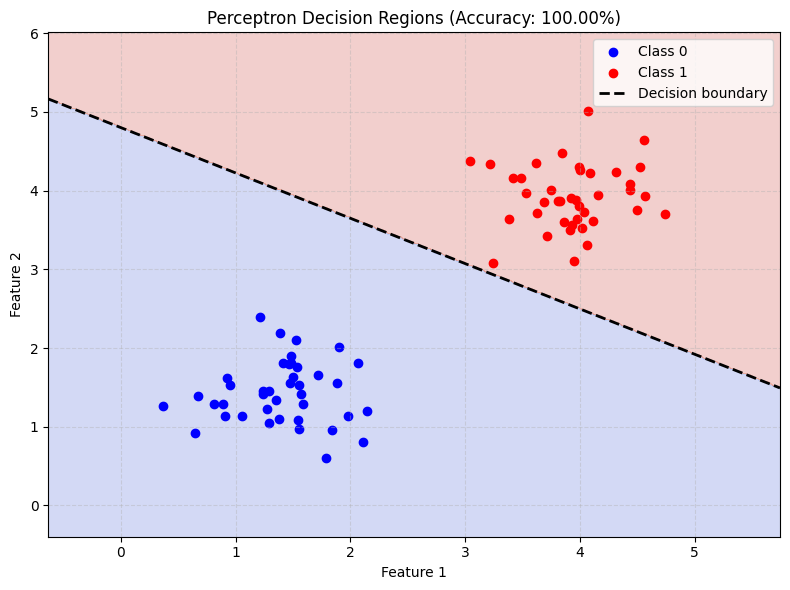

In [16]:
if __name__ == "__main__":
    main()